In [1]:
import pandas as pd

In [2]:
df=pd.read_csv("C:/Users/NIKHIL/Downloads/vscode.python/cleaned_expenses.csv")
df.head()

,Date,Category,Description,Amount,Type,Unnamed: 5,Month,Day,Weekday
0,2024-04-01,Food,Pizza,NaN,250,Expense,April,1,Monday
1,2024-04-02,Salary,Monthly,NaN,50000,Income,April,2,Tuesday
2,2024-04-03,Transport,Uber,NaN,350,Expense,April,3,Wednesday
3,2024-04-04,Bills,Electricity,NaN,1200,Expense,April,4,Thursday


In [3]:
 #Show the first few rows
print("🔍 Preview:")
print(df.head())


🔍 Preview:
         Date   Category  Description  Amount   Type Unnamed: 5  Month  Day  \
0  2024-04-01       Food        Pizza     NaN    250    Expense  April    1   
1  2024-04-02     Salary      Monthly     NaN  50000     Income  April    2   
2  2024-04-03  Transport         Uber     NaN    350    Expense  April    3   
3  2024-04-04      Bills  Electricity     NaN   1200    Expense  April    4   

     Weekday  
0     Monday  
1    Tuesday  
2  Wednesday  
3   Thursday  


In [4]:
# Data types and non-null values
print("\n📊 Dataset Info:")
print(df.info())

# Basic statistics for numeric columns
print("\n📈 Descriptive Stats:")
print(df.describe())




📊 Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4 entries, 0 to 3
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Date         4 non-null      object 
 1   Category     4 non-null      object 
 2   Description  4 non-null      object 
 3   Amount       0 non-null      float64
 4   Type         4 non-null      int64  
 5   Unnamed: 5   4 non-null      object 
 6   Month        4 non-null      object 
 7   Day          4 non-null      int64  
 8   Weekday      4 non-null      object 
dtypes: float64(1), int64(2), object(6)
memory usage: 420.0+ bytes
None

📈 Descriptive Stats:
       Amount          Type       Day
count     0.0      4.000000  4.000000
mean      NaN  12950.000000  2.500000
std       NaN  24703.677189  1.290994
min       NaN    250.000000  1.000000
25%       NaN    325.000000  1.750000
50%       NaN    775.000000  2.500000
75%       NaN  13400.000000  3.250000
max       NaN  50000.00

In [5]:
# Checking for missing values
print("\n❓ Missing Values:")
print(df.isnull().sum())

# Checking unique responses for categorical fields
print("\n🧾 Unique Poll Options:")
print("Preferred Tool:", df['Preferred Tool'].unique())
print("Satisfaction Ratings:", df['Satisfaction (1-5)'].unique())




❓ Missing Values:
Date           0
Category       0
Description    0
Amount         4
Type           0
Unnamed: 5     0
Month          0
Day            0
Weekday        0
dtype: int64

🧾 Unique Poll Options:


KeyError: 'Preferred Tool'

In [ ]:
# Remove duplicate entries
df = df.drop_duplicates()

# Check for missing values
print(df.isnull().sum())


Timestamp             0
Age Group             0
Gender                0
Preferred Tool        0
Satisfaction (1-5)    0
Feedback              0
Unnamed: 6            2
dtype: int64


In [ ]:
# Drop rows where critical columns are missing (e.g., satisfaction or feedback)
df = df.dropna(subset=['Preferred Tool', 'Satisfaction (1-5)'])



In [ ]:

# Strip extra spaces and unify case for consistency
df['Preferred Tool'] = df['Preferred Tool'].str.strip().str.title()


In [ ]:
# Ensure Satisfaction is numeric
df['Satisfaction (1-5)'] = pd.to_numeric(df['Satisfaction (1-5)'], errors='coerce')


In [ ]:
# Ensure Timestamp is a datetime object
df['Timestamp'] = pd.to_datetime(df['Timestamp'])


In [ ]:
# Extract date from timestamp
df['Date'] = df['Timestamp'].dt.date



In [ ]:
# Create feedback length column
df['Feedback Length'] = df['Feedback'].astype(str).apply(len)


In [ ]:
df.to_csv("cleaned_poll_data.csv", index=False)
print("✅ Cleaned data saved to 'cleaned_poll_data.csv'")

✅ Cleaned data saved to 'cleaned_poll_data.csv'


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns


C:\Users\NIKHIL\AppData\Local\Temp\ipykernel_5948\653337876.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Preferred Tool', data=df, palette='Set3')


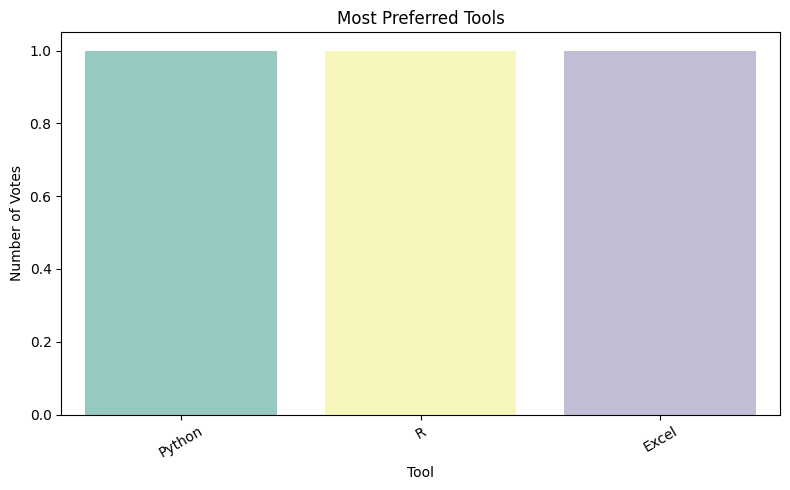

In [ ]:
plt.figure(figsize=(8,5))
sns.countplot(x='Preferred Tool', data=df, palette='Set3')
plt.title('Most Preferred Tools')
plt.xlabel('Tool')
plt.ylabel('Number of Votes')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()


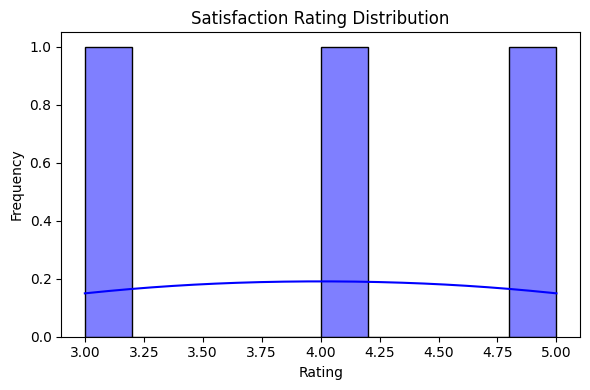

In [ ]:
plt.figure(figsize=(6,4))
sns.histplot(df['Satisfaction (1-5)'],bins=10, kde=True, color='blue')
plt.title('Satisfaction Rating Distribution')
plt.xlabel('Rating')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()


In [ ]:
plt.tight_layout()
plt.show()


<Figure size 640x480 with 0 Axes>

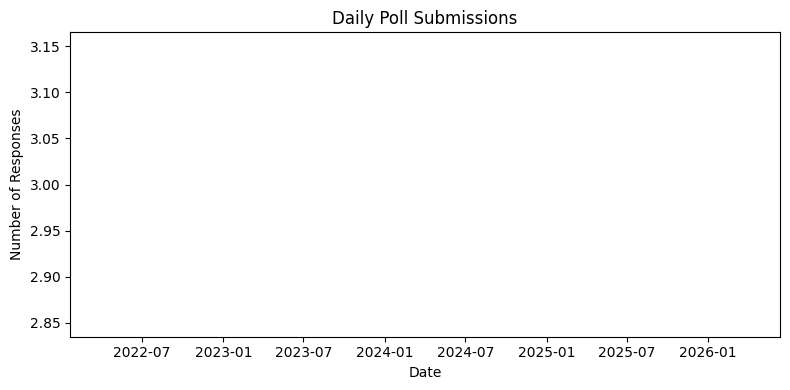

In [ ]:
daily = df.groupby('Date').size()

plt.figure(figsize=(8,4))
daily.plot(kind='line', marker='')
plt.title('Daily Poll Submissions')
plt.xlabel('Date')
plt.ylabel('Number of Responses')

plt.tight_layout()
plt.show()


In [ ]:
from wordcloud import WordCloud



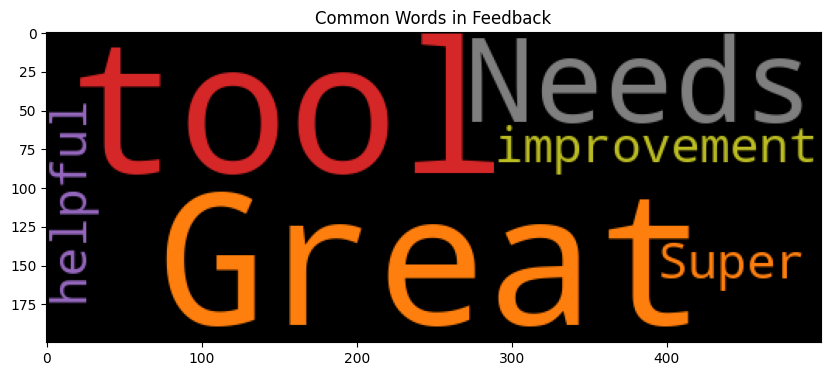

In [ ]:
text = ' '.join(df['Feedback'].astype(str).tolist())

wordcloud = WordCloud(width=500, height=200, background_color='black', colormap='tab10').generate(text)

plt.figure(figsize=(10,5))
plt.imshow(wordcloud, interpolation='hanning')
plt.axis('on')
plt.title("Common Words in Feedback")
plt.show()



C:\Users\NIKHIL\AppData\Local\Temp\ipykernel_5948\3507469775.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Satisfaction (1-5)', y='Feedback Length', data=df, palette='coolwarm')


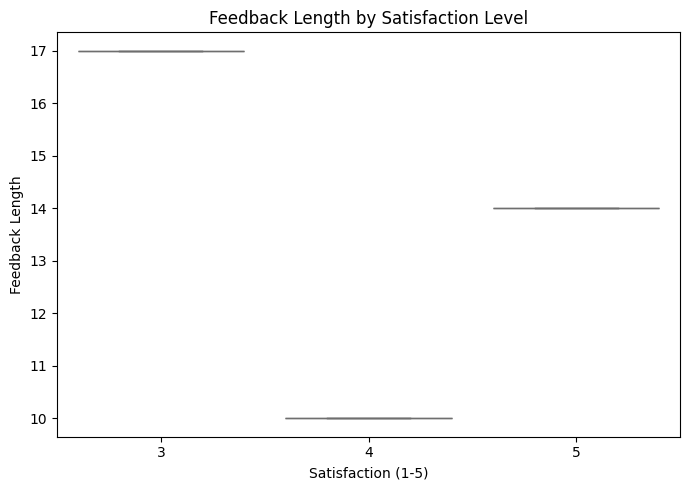

In [ ]:
plt.figure(figsize=(7,5))
sns.boxplot(x='Satisfaction (1-5)', y='Feedback Length', data=df, palette='coolwarm')
plt.title('Feedback Length by Satisfaction Level')
plt.tight_layout()
plt.show()


In [ ]:
pip install streamlit


Note: you may need to restart the kernel to use updated packages.


In [ ]:
import streamlit as st


In [ ]:
import streamlit as st
import pandas as pd
import matplotlib.pyplot as plt
from wordcloud import WordCloud




In [ ]:
df = pd.read_csv('cleaned_poll_data.csv')
st.title("Poll Results Visualizer")

2026-04-08 08:04:31.015 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.


2026-04-08 08:04:32.164 
  command:

    streamlit run C:\Users\NIKHIL\AppData\Roaming\Python\Python311\site-packages\ipykernel_launcher.py [ARGUMENTS]
2026-04-08 08:04:32.165 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-08 08:04:32.166 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.


DeltaGenerator()

In [ ]:
st.title("📊 Poll Results Visualizer")

2026-04-08 08:04:32.189 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-08 08:04:32.192 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-08 08:04:32.194 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.


DeltaGenerator()

In [ ]:
# Sidebar filters
st.sidebar.header("Filter Responses")
selected_tool = st.sidebar.multiselect("Select Preferred Tool(s):", df['Preferred Tool'].unique(), default=df['Preferred Tool'].unique())

filtered_df = df[df['Preferred Tool'].isin(selected_tool)]


2026-04-08 08:04:32.224 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-08 08:04:32.225 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-08 08:04:32.226 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-08 08:04:32.228 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-08 08:04:32.229 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-08 08:04:32.231 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-08 08:04:32.233 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-08 08:04:32.235 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bar

In [ ]:
# Show dataset preview
if st.checkbox("Show Raw Data"):
    st.dataframe(filtered_df)


2026-04-08 08:04:32.251 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-08 08:04:32.252 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-08 08:04:32.253 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-08 08:04:32.254 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-08 08:04:32.254 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-08 08:04:32.255 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.


In [ ]:
# Bar chart - Preferred Tools
st.subheader("Tool Preference")
tool_counts = filtered_df['Preferred Tool'].value_counts()
st.bar_chart(tool_counts)


2026-04-08 08:04:32.271 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-08 08:04:32.273 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-08 08:04:32.273 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-08 08:04:33.385 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-08 08:04:33.386 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-08 08:04:33.386 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.


DeltaGenerator()

2026-04-08 08:04:33.397 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-08 08:04:33.399 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-08 08:04:33.399 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-08 08:04:33.453 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-08 08:04:33.536 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-08 08:04:33.536 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-08 08:04:33.536 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.


DeltaGenerator()

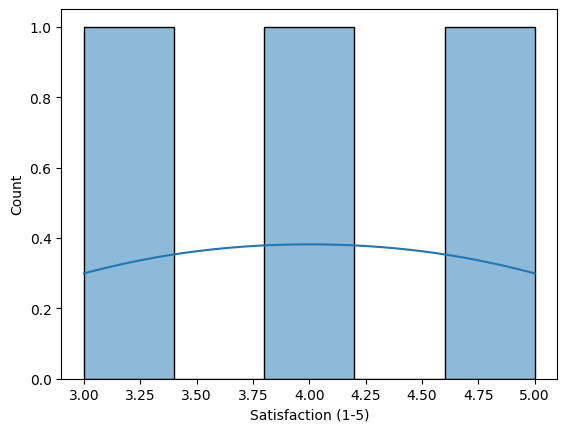

In [ ]:
# Histogram - Satisfaction Ratings
st.subheader("Satisfaction Ratings")
fig, ax = plt.subplots()
sns.histplot(filtered_df['Satisfaction (1-5)'], bins=5, kde=True, ax=ax)
st.pyplot(fig)


In [ ]:
# Line plot - Submissions Over Time
st.subheader("Responses Over Time")
df['Date'] = pd.to_datetime(df['Timestamp']).dt.date
daily = df.groupby('Date').size()
st.line_chart(daily)


2026-04-08 08:04:33.629 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-08 08:04:33.629 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-08 08:04:33.629 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-08 08:04:33.718 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-08 08:04:33.719 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-08 08:04:33.719 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.


DeltaGenerator()

In [ ]:
# Word Cloud - Feedback
st.subheader("Feedback Word Cloud")
text = ' '.join(filtered_df['Feedback'].dropna().astype(str))
if text:
    wordcloud = WordCloud(width=800, height=400, background_color='white').generate(text)
    fig_wc, ax_wc = plt.subplots()
    ax_wc.imshow(wordcloud, interpolation='bilinear')
    ax_wc.axis('off')
    st.pyplot(fig_wc)
else:
    st.write("No feedback available to generate word cloud.")


2026-04-08 08:04:33.735 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-08 08:04:33.737 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-08 08:04:33.737 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-08 08:04:33.838 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-08 08:04:33.886 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-08 08:04:33.886 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-08 08:04:33.886 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.


In [ ]:
streamlit run app.py


SyntaxError: invalid syntax (507122745.py, line 1)